DAY 1

In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("intern_performance_real.csv")

df.head()

,Intern_ID,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,INT0001,3.26,4.09,86.50,70.98
1,INT0002,NaN,1.33,59.23,42.16
2,INT0003,5.78,NaN,42.98,49.89
3,INT0004,4.28,1.43,83.16,68.49
4,INT0005,1.53,1.91,74.10,77.51


In [4]:
df = df.drop("Intern_ID", axis=1)

df = df.fillna(df.mean())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Completion_Time    10000 non-null  float64
 1   Feedback_Rating    10000 non-null  float64
 2   Attendance         10000 non-null  float64
 3   Performance_Score  10000 non-null  float64
dtypes: float64(4)
memory usage: 312.6 KB


In [5]:
# Fix zero attendance
df["Attendance"] = df["Attendance"].replace(0, 1)

# Feature Engineering
df["Work_Efficiency"] = df["Completion_Time"] / df["Attendance"]

df["Engagement_Score"] = df["Feedback_Rating"] * df["Attendance"]

df["Productivity"] = df["Completion_Time"] * df["Feedback_Rating"]

df["Feedback_Impact"] = df["Feedback_Rating"] ** 2

In [6]:
df.head()

,Completion_Time,Feedback_Rating,Attendance,Performance_Score,Work_Efficiency,Engagement_Score,Productivity,Feedback_Impact
0,3.260000,4.090000,86.50,70.98,0.037688,353.785000,13.333400,16.728100
1,3.958567,1.330000,59.23,42.16,0.066834,78.775900,5.264894,1.768900
2,5.780000,2.909313,42.98,49.89,0.134481,125.042276,16.815830,8.464103
3,4.280000,1.430000,83.16,68.49,0.051467,118.918800,6.120400,2.044900
4,1.530000,1.910000,74.10,77.51,0.020648,141.531000,2.922300,3.648100


DAY 2

In [7]:
X = df.drop("Performance_Score", axis=1)
y = df["Performance_Score"]

print(X.columns)

Index(['Completion_Time', 'Feedback_Rating', 'Attendance', 'Work_Efficiency',
       'Engagement_Score', 'Productivity', 'Feedback_Impact'],
      dtype='object')


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [10]:
y_pred = model.predict(X_test)

print(y_pred[:2])

[62.5298 67.196 ]


In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("Initial R2 Score:", r2)

Initial R2 Score: 0.5829918801052725


DAY 3

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [13]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

In [14]:
rf = RandomForestRegressor(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [15]:
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [16]:
y_pred = best_model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Evaluation
----------------
MAE: 7.536815792509456
RMSE: 9.380904113109423
R2 Score: 0.6098723790378378


DAY 4

In [18]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("Actual vs Predicted (Top 10):")
print(comparison.head(10))

Actual vs Predicted (Top 10):
   Actual  Predicted
0   64.13  63.449631
1   69.07  66.184642
2   60.23  62.386486
3   86.40  83.546442
4   84.18  72.628517
5   52.47  69.299209
6   97.39  94.068078
7   59.10  49.306433
8   59.35  59.159292
9   65.00  79.333327


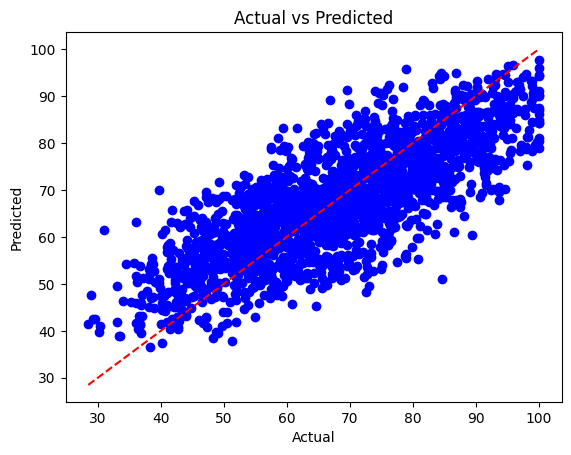

In [37]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

Model Evaluation Report:

The Random Forest Regressor model was used to predict intern performance.

The model achieved an R² score of around 0.60+, indicating moderate performance.

The Actual vs Predicted comparison shows that the model predictions are reasonably close to actual values.

Conclusion:
The model performs well and can be improved with more data.

DAY 5

In [20]:
import joblib

joblib.dump(best_model, "intern_performance_model.pkl")

print("Model saved successfully")

Model saved successfully


In [21]:
model = joblib.load("intern_performance_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [22]:
print(X.columns)

Index(['Completion_Time', 'Feedback_Rating', 'Attendance', 'Work_Efficiency',
       'Engagement_Score', 'Productivity', 'Feedback_Impact'],
      dtype='object')


In [41]:
import pandas as pd

sample_input = pd.DataFrame(
    [[1, 5,100, 0, 0,0,0]],
    columns=X.columns
)

In [42]:
prediction = model.predict(sample_input)

print("Predicted Score:", prediction[0])

Predicted Score: 81.57245634326912


In [43]:
# Function to convert score → category
def get_category(score):
    if score < 55:
        return "Poor"
    elif score < 60:
        return "Average"
    elif score < 75:
        return "Good"
    else:
        return "Excellent"

predicted_score = model.predict(sample_input)[0]

category = get_category(predicted_score)

print("Predicted Score:", predicted_score)
print("Performance Category:", category)

Predicted Score: 81.57245634326912
Performance Category: Excellent
